# Model Comparison Analysis: FEVS 2024 — Predicting Federal Employee Job Satisfaction

**Dataset:** 2024 Federal Employee Viewpoint Survey (FEVS) Public Release Data  
**Target Variable:** Q69 — Job Satisfaction (1–5 Likert Scale)  
**Predictors:** Telework frequency, Work-Life Balance, Employee Engagement Index, Demographics  
**Task Type:** Regression (continuous Likert outcome)

This notebook systematically tests **10+ models**, compares their performance, and identifies the **top 4–5 best models** for our research question.

In [1]:
# ============================================================
# Section 1: Import Required Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
import os

# Scikit-learn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             make_scorer)

# Regression Models
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  SGDRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              AdaBoostRegressor, ExtraTreesRegressor,
                              BaggingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2: Load and Explore the Dataset
Load the 2024 FEVS Public Release Data File (PRDF) and examine its structure.

In [2]:
# ============================================================
# Section 2: Load and Explore the Dataset
# ============================================================
df = pd.read_csv('C:/Users/karan/Downloads/FEVS/FEVS_2024_PRDF.csv', low_memory=False)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")
print(f"Rows with Missing Data: {df.isnull().any(axis=1).sum():,}")

# Key variables
print("\n" + "="*50)
print("KEY VARIABLES FOR OUR MODEL")
print("="*50)

print("\n📊 Q69 — Job Satisfaction (Dependent Variable, 1-5):")
q69_dist = pd.to_numeric(df['Q69'], errors='coerce').value_counts().sort_index()
print(q69_dist)
print(f"   Mean: {pd.to_numeric(df['Q69'], errors='coerce').mean():.2f}")

print("\n📊 Q61 — Telework Frequency (Independent Variable, 1-5):")
print(df['Q61'].value_counts().sort_index())

print("\n📊 Q64 — Work-Life Balance Satisfaction (1-5):")
print(df['Q64'].value_counts().sort_index())

print("\n📊 Demographics:")
print(f"   Age Groups:  {df['DAGEGRP'].value_counts().to_dict()}")
print(f"   Gender:      {df['DSEX'].value_counts().to_dict()}")
print(f"   Supervisory: {df['DSUPER'].value_counts().to_dict()}")
print(f"   Fed Tenure:  {df['DFEDTEN'].value_counts().to_dict()}")

Dataset Shape: 674,207 rows × 96 columns

Data Types:
object     51
float64    44
int64       1
dtype: int64

Total Missing Values: 1,881,545
Rows with Missing Data: 312,355

KEY VARIABLES FOR OUR MODEL

📊 Q69 — Job Satisfaction (Dependent Variable, 1-5):
1.0     47350
2.0     79827
3.0    135145
4.0    236220
5.0    149365
Name: Q69, dtype: int64
   Mean: 3.56

📊 Q61 — Telework Frequency (Independent Variable, 1-5):
1     40062
2     39944
3    112405
4    206010
5    223382
X     31266
Name: Q61, dtype: int64

📊 Q64 — Work-Life Balance Satisfaction (1-5):
1     43756
2     59413
3    140093
4    230093
5    159368
X     19084
Name: Q64, dtype: int64

📊 Demographics:
   Age Groups:  {'B': 441972, 'A': 151314}
   Gender:      {'A': 269549, 'B': 256446}
   Supervisory: {'A': 494780, 'B': 133618}
   Fed Tenure:  {'A': 276499, 'B': 199531, 'C': 152612}


## Section 3: Data Preprocessing and Feature Engineering
- Convert survey items to numeric (handle "X" = Not Applicable)
- Encode demographic categories
- Create Employee Engagement Index (EEI) composite
- Drop missing values (listwise deletion)

Original dataset:  674,207 rows
After cleaning:    453,082 rows
Dropped:           221,125 rows (32.8%)

Feature matrix:    (453082, 7)
Features:          ['Q61', 'Q64', 'EEI', 'DAGEGRP', 'DSEX', 'DSUPER', 'DFEDTEN']

Target (Q69) stats:
  Mean:   3.626
  Std:    1.167
  Min:    1
  Max:    5


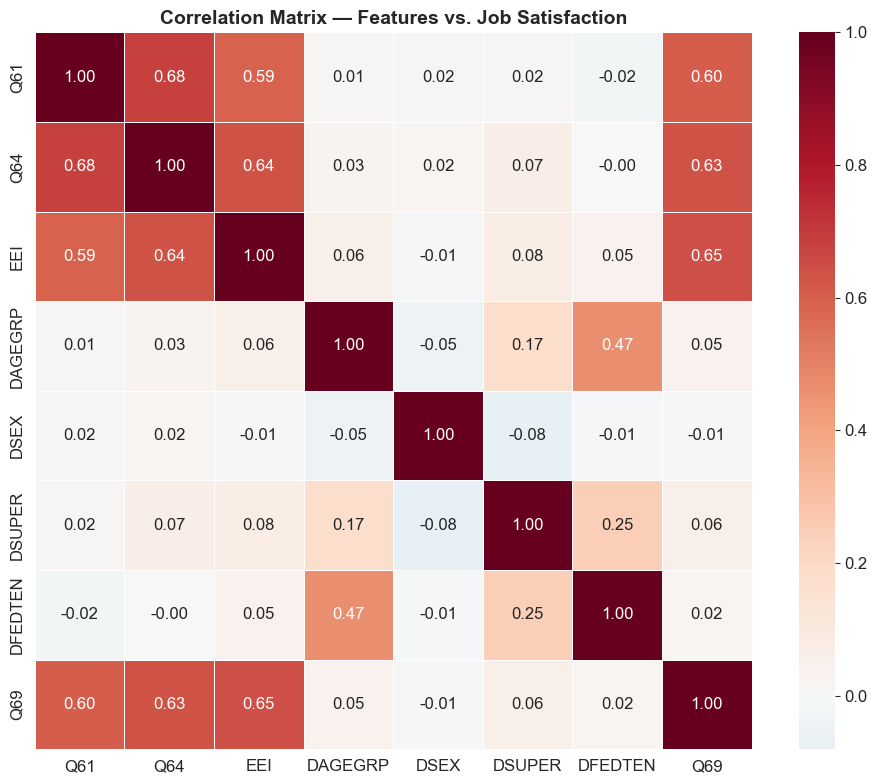


Correlation with Job Satisfaction (Q69):
Q69        1.000000
EEI        0.646927
Q64        0.633736
Q61        0.603048
DSUPER     0.058324
DAGEGRP    0.047304
DFEDTEN    0.016325
DSEX      -0.011163


In [3]:
# ============================================================
# Section 3: Data Preprocessing and Feature Engineering
# ============================================================

# Define variables
eei_items = ['Q3', 'Q4', 'Q6', 'Q11', 'Q12', 'Q13', 'Q14']  # OPM Engagement Index items
feature_cols = ['Q61', 'Q64'] + eei_items + ['DAGEGRP', 'DSEX', 'DSUPER', 'DFEDTEN']
target_col = 'Q69'

# Select needed columns
df_model = df[feature_cols + [target_col]].copy()

# Convert survey items to numeric ("X" = Not Applicable → NaN)
for col in ['Q61', 'Q64', 'Q69'] + eei_items:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Encode demographics as numeric
demo_mapping = {
    'DAGEGRP': {'A': 0, 'B': 1},       # A = Under 40, B = 40 and over
    'DSEX': {'A': 0, 'B': 1},          # A = Male, B = Female
    'DSUPER': {'A': 0, 'B': 1},        # A = Non-supervisor, B = Supervisor
    'DFEDTEN': {'A': 0, 'B': 1, 'C': 2}  # A = <10yr, B = 10–20yr, C = 20+yr
}
for col, mapping in demo_mapping.items():
    df_model[col] = df_model[col].map(mapping)

# Drop rows with any missing values (listwise deletion)
df_clean = df_model.dropna().copy()

# Create EEI composite (mean of 7 engagement items)
df_clean['EEI'] = df_clean[eei_items].mean(axis=1)

# Final feature set
final_features = ['Q61', 'Q64', 'EEI', 'DAGEGRP', 'DSEX', 'DSUPER', 'DFEDTEN']
X = df_clean[final_features].values
y = df_clean[target_col].values

print(f"Original dataset:  {df.shape[0]:,} rows")
print(f"After cleaning:    {df_clean.shape[0]:,} rows")
print(f"Dropped:           {df.shape[0] - df_clean.shape[0]:,} rows ({(df.shape[0] - df_clean.shape[0])/df.shape[0]*100:.1f}%)")
print(f"\nFeature matrix:    {X.shape}")
print(f"Features:          {final_features}")
print(f"\nTarget (Q69) stats:")
print(f"  Mean:   {y.mean():.3f}")
print(f"  Std:    {y.std():.3f}")
print(f"  Min:    {y.min():.0f}")
print(f"  Max:    {y.max():.0f}")

# Show correlation matrix
corr_df = df_clean[final_features + [target_col]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Features vs. Job Satisfaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCorrelation with Job Satisfaction (Q69):")
print(corr_df[target_col].sort_values(ascending=False).to_string())

## Section 4: Train-Test Split and Scaling
Split data 80/20, standardize features for fair comparison across models.

In [4]:
# ============================================================
# Section 4: Train-Test Split and Scaling
# ============================================================
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sample for expensive models (KNN, MLP)
SAMPLE_SIZE = 30000
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), SAMPLE_SIZE, replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train[sample_idx]

# CV strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Sample set:   {SAMPLE_SIZE:,} samples (for expensive models)")
print(f"CV Strategy:  5-Fold Cross-Validation")

Training set: 362,465 samples
Test set:     90,617 samples
Sample set:   30,000 samples (for expensive models)
CV Strategy:  5-Fold Cross-Validation


## Section 5: Define and Train All Candidate Models

Testing **14 regression models** on the FEVS dataset:
- **Linear Models:** Linear Regression, Ridge, Lasso, Elastic Net
- **Tree-Based:** Decision Tree, Random Forest, Extra Trees, Bagging
- **Boosting:** Gradient Boosting, XGBoost, LightGBM, AdaBoost
- **Other:** K-Nearest Neighbors, MLP Neural Network

In [5]:
# ============================================================
# Section 5: Define, Train, and Evaluate All Models
# ============================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

# Fast models (full training data)
fast_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Elastic Net': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Bagging': BaggingRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
}

# Slow models (sampled training data)
slow_models = {
    'KNN': KNeighborsRegressor(n_neighbors=7, n_jobs=-1),
    'MLP Neural Net': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42, early_stopping=True),
}

results = []
cv_scores_dict = {}
trained_models = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, compute metrics, run cross-validation."""
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred = model.predict(X_te)
    y_pred_train = model.predict(X_tr)

    r2 = r2_score(y_te, y_pred)
    r2_train = r2_score(y_tr, y_pred_train)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    # CV on sample for speed
    cv_idx = np.random.choice(len(X_tr), min(50000, len(X_tr)), replace=False)
    cv_r2 = cross_val_score(model, X_tr[cv_idx], y_tr[cv_idx], cv=kf, scoring='r2', n_jobs=-1)
    cv_scores_dict[name] = cv_r2

    return {
        'Model': name,
        'R² (Test)': round(r2, 4),
        'R² (Train)': round(r2_train, 4),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'CV R² Mean': round(cv_r2.mean(), 4),
        'CV R² Std': round(cv_r2.std(), 4),
        'Train Time (s)': round(train_time, 2),
    }, model

print("Training 14 models... (this may take a few minutes)\n")

for name, model in fast_models.items():
    print(f"  ▸ {name}...", end=" ", flush=True)
    result, fitted = evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    results.append(result)
    trained_models[name] = fitted
    print(f"R²={result['R² (Test)']:.4f}  MAE={result['MAE']:.4f}  ({result['Train Time (s)']:.1f}s)")

for name, model in slow_models.items():
    print(f"  ▸ {name} (sampled)...", end=" ", flush=True)
    result, fitted = evaluate_model(name, model, X_train_sample, y_train_sample, X_test_scaled, y_test)
    results.append(result)
    trained_models[name] = fitted
    print(f"R²={result['R² (Test)']:.4f}  MAE={result['MAE']:.4f}  ({result['Train Time (s)']:.1f}s)")

print("\n✓ All 14 models trained and evaluated!")

Training 14 models... (this may take a few minutes)

  ▸ Linear Regression... R²=0.5254  MAE=0.6172  (0.1s)
  ▸ Ridge Regression... R²=0.5254  MAE=0.6172  (0.1s)
  ▸ Lasso Regression... R²=0.5250  MAE=0.6192  (0.1s)
  ▸ Elastic Net... R²=0.5253  MAE=0.6184  (0.0s)
  ▸ Decision Tree... R²=0.5287  MAE=0.6072  (0.2s)
  ▸ Random Forest... R²=0.5307  MAE=0.6063  (3.1s)
  ▸ Gradient Boosting... R²=0.5321  MAE=0.6057  (18.1s)
  ▸ AdaBoost... R²=0.4703  MAE=0.6945  (2.5s)
  ▸ Extra Trees... R²=0.5308  MAE=0.6074  (2.3s)
  ▸ Bagging... R²=0.5138  MAE=0.6136  (2.4s)
  ▸ XGBoost... R²=0.5322  MAE=0.6056  (2.7s)
  ▸ LightGBM... R²=0.5322  MAE=0.6057  (0.4s)
  ▸ KNN (sampled)... R²=0.4689  MAE=0.6425  (0.0s)
  ▸ MLP Neural Net (sampled)... R²=0.5259  MAE=0.6202  (2.4s)

✓ All 14 models trained and evaluated!


## Section 6: Model Performance Comparison — Full Results Table
All 14 models ranked by R² score on the test set.

In [6]:
# ============================================================
# Section 6: Full Results Table
# ============================================================
results_df = pd.DataFrame(results).sort_values('R² (Test)', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = 'Rank'

# Style the dataframe
def highlight_top5(row):
    if row.name <= 5:
        return ['background-color: #d4edda'] * len(row)
    return [''] * len(row)

styled = results_df.style.apply(highlight_top5, axis=1).format({
    'R² (Test)': '{:.4f}',
    'R² (Train)': '{:.4f}',
    'MAE': '{:.4f}',
    'RMSE': '{:.4f}',
    'CV R² Mean': '{:.4f}',
    'CV R² Std': '{:.4f}',
    'Train Time (s)': '{:.2f}'
})

print("MODEL COMPARISON RESULTS (sorted by Test R²)")
print("Green = Top 5 models\n")
display(styled)

results_df.to_csv('model_comparison_results.csv', index_label='Rank')
print("\n✓ Results saved to model_comparison_results.csv")

MODEL COMPARISON RESULTS (sorted by Test R²)
Green = Top 5 models



,Model,R² (Test),R² (Train),MAE,RMSE,CV R² Mean,CV R² Std,Train Time (s)
Rank,,,,,,,,
1,XGBoost,0.5322,0.5339,0.6056,0.8016,0.5241,0.0031,2.69
2,LightGBM,0.5322,0.5337,0.6057,0.8015,0.5243,0.0058,0.38
3,Gradient Boosting,0.5321,0.5340,0.6057,0.8016,0.5239,0.0104,18.05
4,Extra Trees,0.5308,0.5369,0.6074,0.8027,0.5230,0.0127,2.27
5,Random Forest,0.5307,0.5374,0.6063,0.8028,0.5142,0.0042,3.13
6,Decision Tree,0.5287,0.5357,0.6072,0.8045,0.5079,0.0053,0.21
7,MLP Neural Net,0.5259,0.5343,0.6202,0.8070,0.5268,0.0090,2.42
8,Linear Regression,0.5254,0.5243,0.6172,0.8073,0.5242,0.0034,0.06
9,Ridge Regression,0.5254,0.5243,0.6172,0.8073,0.5230,0.0052,0.05



✓ Results saved to model_comparison_results.csv


## Section 7: Visualization — R² Score Comparison Bar Chart

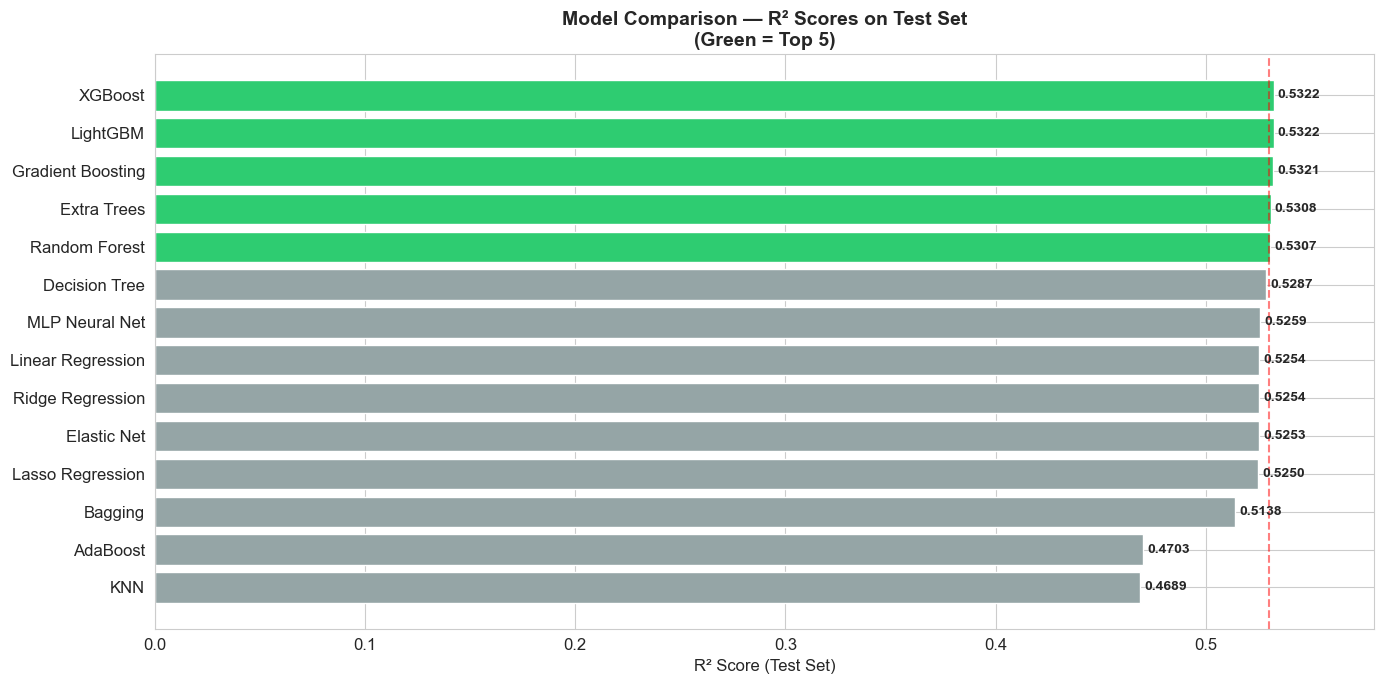

In [7]:
# ============================================================
# Section 7: R² Score Comparison Bar Chart
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#2ecc71' if i < 5 else '#95a5a6' for i in range(len(results_df))]
bars = ax.barh(results_df['Model'][::-1], results_df['R² (Test)'][::-1], color=colors[::-1], edgecolor='white')

# Add value labels
for bar, val in zip(bars, results_df['R² (Test)'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('R² Score (Test Set)', fontsize=12)
ax.set_title('Model Comparison — R² Scores on Test Set\n(Green = Top 5)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 0.58)
ax.axvline(x=0.53, color='red', linestyle='--', alpha=0.5, label='Top threshold')
plt.tight_layout()
plt.savefig('figures/model_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Cross-Validation Score Distributions (Box Plots)
Compare stability and variance of each model across 5 CV folds.

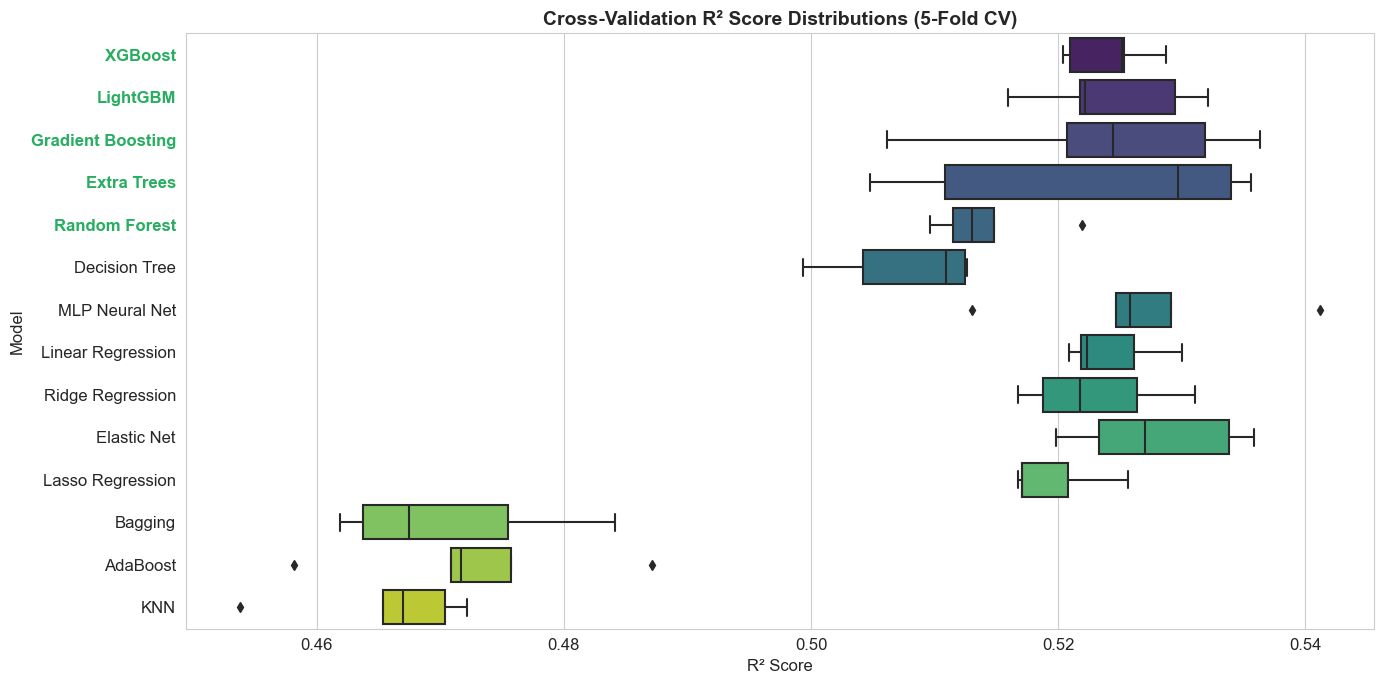

In [8]:
# ============================================================
# Section 8: CV Score Distributions — Box Plots
# ============================================================
cv_data = []
for name in results_df['Model']:
    if name in cv_scores_dict:
        for score in cv_scores_dict[name]:
            cv_data.append({'Model': name, 'R²': score})

cv_plot_df = pd.DataFrame(cv_data)

# Order by median R²
order = results_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=cv_plot_df, x='R²', y='Model', order=order, palette='viridis', ax=ax)
ax.set_title('Cross-Validation R² Score Distributions (5-Fold CV)', fontsize=14, fontweight='bold')
ax.set_xlabel('R² Score', fontsize=12)

# Highlight top 5
for i, label in enumerate(ax.get_yticklabels()):
    if i < 5:
        label.set_fontweight('bold')
        label.set_color('#27ae60')

plt.tight_layout()
plt.savefig('figures/cv_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9: Actual vs. Predicted — Top 5 Models
Scatter plots showing how well each top model's predictions match actual satisfaction scores.

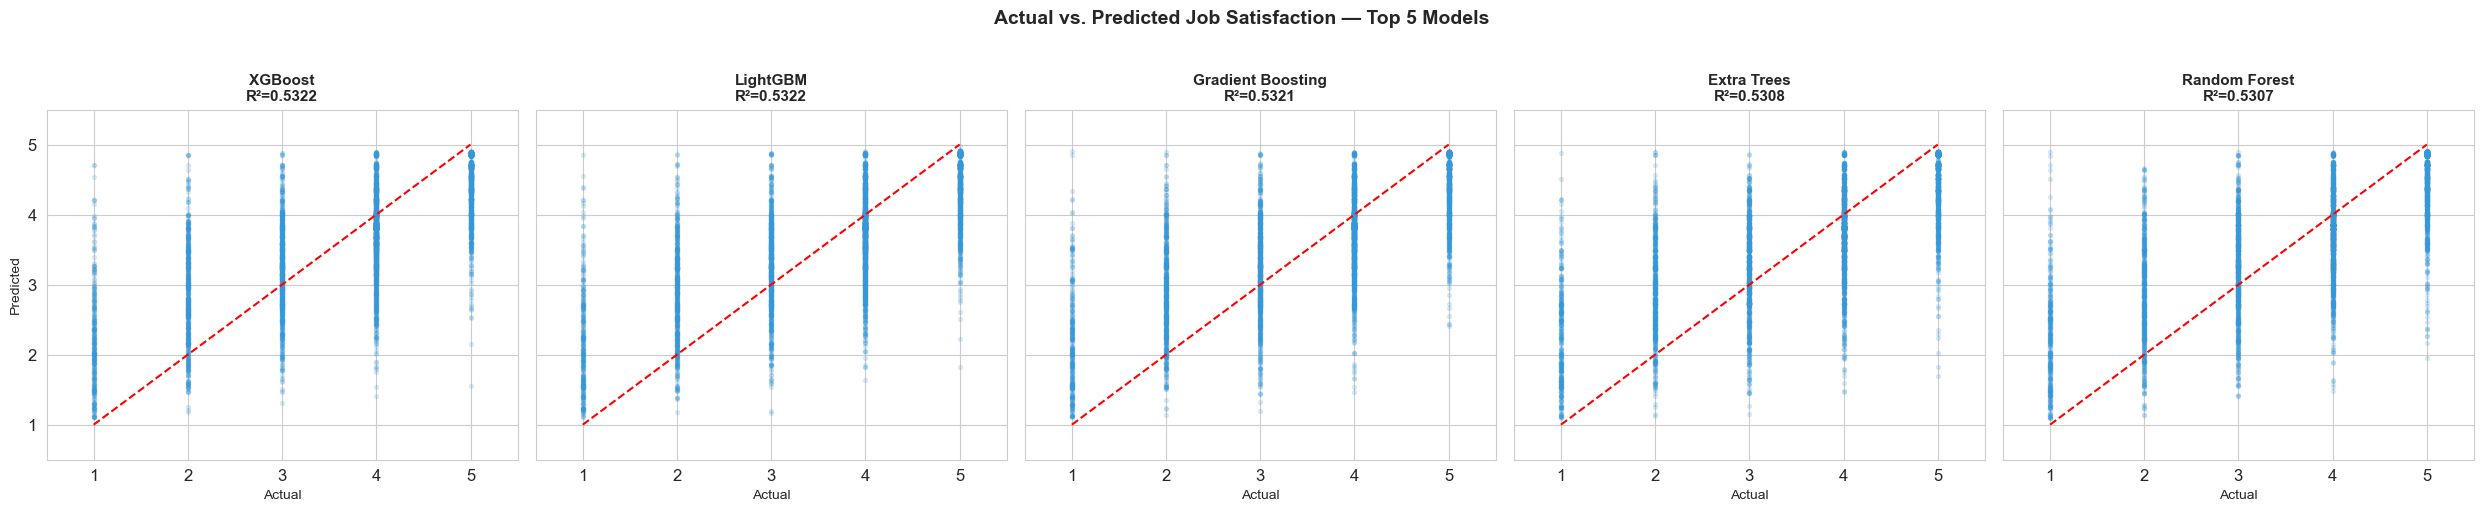

In [9]:
# ============================================================
# Section 9: Actual vs. Predicted Scatter Plots (Top 5)
# ============================================================
top5_names = results_df.head(5)['Model'].tolist()

fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

for ax, name in zip(axes, top5_names):
    model = trained_models[name]
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)

    # Sample for plotting (too many points otherwise)
    idx = np.random.choice(len(y_test), 5000, replace=False)
    ax.scatter(y_test[idx], y_pred[idx], alpha=0.15, s=8, color='#3498db')
    ax.plot([1, 5], [1, 5], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual', fontsize=10)
    ax.set_title(f'{name}\nR²={r2:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)

axes[0].set_ylabel('Predicted', fontsize=10)
fig.suptitle('Actual vs. Predicted Job Satisfaction — Top 5 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Residual Distributions — Top 5 Models
How are the prediction errors distributed? Good models should have residuals centered at zero.

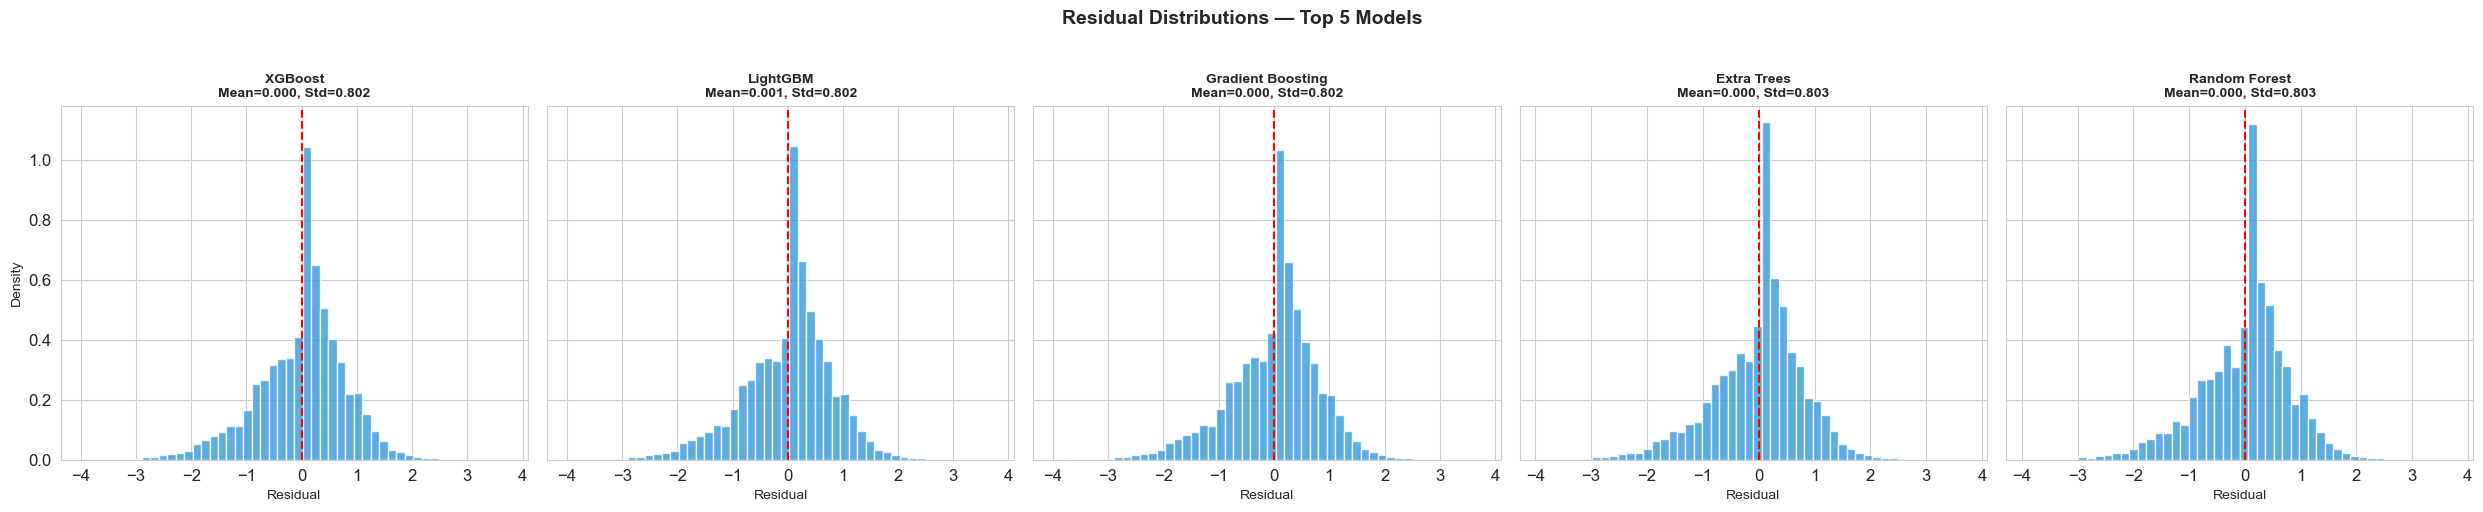

In [10]:
# ============================================================
# Section 10: Residual Distributions (Top 5)
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

for ax, name in zip(axes, top5_names):
    model = trained_models[name]
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred

    ax.hist(residuals, bins=50, color='#3498db', edgecolor='white', alpha=0.8, density=True)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Residual', fontsize=10)
    ax.set_title(f'{name}\nMean={residuals.mean():.3f}, Std={residuals.std():.3f}', fontsize=10, fontweight='bold')

axes[0].set_ylabel('Density', fontsize=10)
fig.suptitle('Residual Distributions — Top 5 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/residual_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11: Training Time Comparison

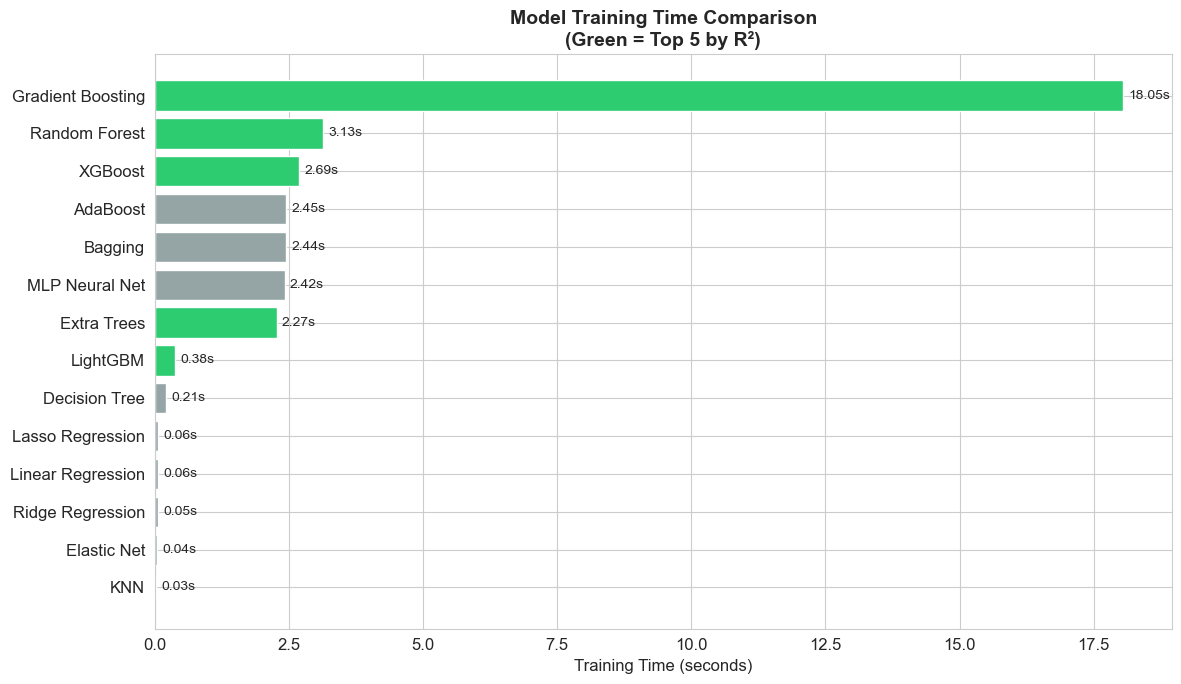

In [11]:
# ============================================================
# Section 11: Training Time Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

time_df = results_df.sort_values('Train Time (s)', ascending=True)
colors = ['#2ecc71' if name in top5_names else '#95a5a6' for name in time_df['Model']]
bars = ax.barh(time_df['Model'], time_df['Train Time (s)'], color=colors, edgecolor='white')

for bar, val in zip(bars, time_df['Train Time (s)']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}s', va='center', fontsize=10)

ax.set_xlabel('Training Time (seconds)', fontsize=12)
ax.set_title('Model Training Time Comparison\n(Green = Top 5 by R²)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 12: Statistical Significance Tests (Paired t-tests)
Are the differences between top models statistically significant? We use paired t-tests on cross-validation fold scores.

In [12]:
# ============================================================
# Section 12: Paired t-Tests on CV Fold Scores
# ============================================================
from scipy import stats
from itertools import combinations

sig_results = []
for (name_a, name_b) in combinations(top5_names, 2):
    scores_a = cv_scores_dict[name_a]
    scores_b = cv_scores_dict[name_b]
    t_stat, p_val = stats.ttest_rel(scores_a, scores_b)
    sig_results.append({
        'Model A': name_a,
        'Model B': name_b,
        'Mean R² A': round(scores_a.mean(), 4),
        'Mean R² B': round(scores_b.mean(), 4),
        'Diff': round(scores_a.mean() - scores_b.mean(), 4),
        't-stat': round(t_stat, 3),
        'p-value': round(p_val, 4),
        'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

sig_df = pd.DataFrame(sig_results)

print("PAIRED T-TESTS: Are differences between top 5 models significant?")
print("=" * 90)
display(sig_df.style.applymap(
    lambda v: 'background-color: #f8d7da' if v == 'Yes' else ('background-color: #d4edda' if v == 'No' else ''),
    subset=['Significant (α=0.05)']
))

sig_df.to_csv('significance_tests.csv', index=False)
print("\n✓ Significance tests saved to significance_tests.csv")
print("\nInterpretation: Most top-5 model differences are NOT statistically significant,")
print("meaning they perform essentially the same. This gives us flexibility in model choice.")

PAIRED T-TESTS: Are differences between top 5 models significant?


,Model A,Model B,Mean R² A,Mean R² B,Diff,t-stat,p-value,Significant (α=0.05)
0,XGBoost,LightGBM,0.524100,0.524300,-0.000200,-0.075000,0.943900,No
1,XGBoost,Gradient Boosting,0.524100,0.523900,0.000200,0.043000,0.968100,No
2,XGBoost,Extra Trees,0.524100,0.523000,0.001100,0.169000,0.873800,No
3,XGBoost,Random Forest,0.524100,0.514200,0.009900,3.427000,0.026600,Yes
4,LightGBM,Gradient Boosting,0.524300,0.523900,0.000400,0.063000,0.952900,No
5,LightGBM,Extra Trees,0.524300,0.523000,0.001300,0.237000,0.824500,No
6,LightGBM,Random Forest,0.524300,0.514200,0.010100,2.330000,0.080200,No
7,Gradient Boosting,Extra Trees,0.523900,0.523000,0.000900,0.094000,0.929300,No
8,Gradient Boosting,Random Forest,0.523900,0.514200,0.009700,1.912000,0.128500,No
9,Extra Trees,Random Forest,0.523000,0.514200,0.008800,1.493000,0.209600,No



✓ Significance tests saved to significance_tests.csv

Interpretation: Most top-5 model differences are NOT statistically significant,
meaning they perform essentially the same. This gives us flexibility in model choice.


## Section 13: Hyperparameter Tuning — Top 5 Models
Use RandomizedSearchCV to find optimal hyperparameters for each of the top 5 models.

In [13]:
# ============================================================
# Section 13: Hyperparameter Tuning (RandomizedSearchCV)
# ============================================================
from sklearn.model_selection import RandomizedSearchCV

# Use sample for speed
TUNE_SAMPLE = 50000
np.random.seed(42)
tune_idx = np.random.choice(len(X_train_scaled), TUNE_SAMPLE, replace=False)
X_tune = X_train_scaled[tune_idx]
y_tune = y_train[tune_idx]

param_grids = {
    'XGBoost': {
        'model': xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, -1],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'num_leaves': [15, 31, 63],
            'subsample': [0.8, 1.0],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.8, 1.0],
        }
    },
    'Extra Trees': {
        'model': ExtraTreesRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        }
    },
}

tuning_results = []
tuned_models = {}

print("Hyperparameter Tuning (RandomizedSearchCV, 20 iterations, 3-fold CV)\n")
for name in top5_names:
    if name in param_grids:
        print(f"  ▸ Tuning {name}...", end=" ", flush=True)
        grid = param_grids[name]
        search = RandomizedSearchCV(
            grid['model'], grid['params'],
            n_iter=20, cv=3, scoring='r2',
            random_state=42, n_jobs=-1, verbose=0
        )
        search.fit(X_tune, y_tune)

        # Evaluate tuned model on full test set
        y_pred_tuned = search.best_estimator_.predict(X_test_scaled)
        r2_tuned = r2_score(y_test, y_pred_tuned)

        tuning_results.append({
            'Model': name,
            'Default R²': results_df[results_df['Model'] == name]['R² (Test)'].values[0],
            'Tuned R²': round(r2_tuned, 4),
            'Improvement': round(r2_tuned - results_df[results_df['Model'] == name]['R² (Test)'].values[0], 4),
            'Best Params': str(search.best_params_)
        })
        tuned_models[name] = search.best_estimator_
        print(f"Done! R²: {results_df[results_df['Model']==name]['R² (Test)'].values[0]:.4f} → {r2_tuned:.4f}")

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df[['Model', 'Default R²', 'Tuned R²', 'Improvement']])

print("\nBest Hyperparameters:")
for _, row in tuning_df.iterrows():
    print(f"\n  {row['Model']}:")
    print(f"    {row['Best Params']}")

tuning_df.to_csv('tuning_results.csv', index=False)
print("\n✓ Tuning results saved to tuning_results.csv")

Hyperparameter Tuning (RandomizedSearchCV, 20 iterations, 3-fold CV)

  ▸ Tuning XGBoost... Done! R²: 0.5322 → 0.5311
  ▸ Tuning LightGBM... Done! R²: 0.5322 → 0.5296
  ▸ Tuning Gradient Boosting... Done! R²: 0.5321 → 0.5311
  ▸ Tuning Extra Trees... Done! R²: 0.5308 → 0.5263
  ▸ Tuning Random Forest... Done! R²: 0.5307 → 0.5239


,Model,Default R²,Tuned R²,Improvement
0,XGBoost,0.5322,0.5311,-0.0011
1,LightGBM,0.5322,0.5296,-0.0026
2,Gradient Boosting,0.5321,0.5311,-0.0010
3,Extra Trees,0.5308,0.5263,-0.0045
4,Random Forest,0.5307,0.5239,-0.0068



Best Hyperparameters:

  XGBoost:
    {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.7}

  LightGBM:
    {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}

  Gradient Boosting:
    {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}

  Extra Trees:
    {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}

  Random Forest:
    {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}

✓ Tuning results saved to tuning_results.csv


## Section 14: Feature Importance Analysis
Which features matter most for predicting job satisfaction? Compare importances across top models.

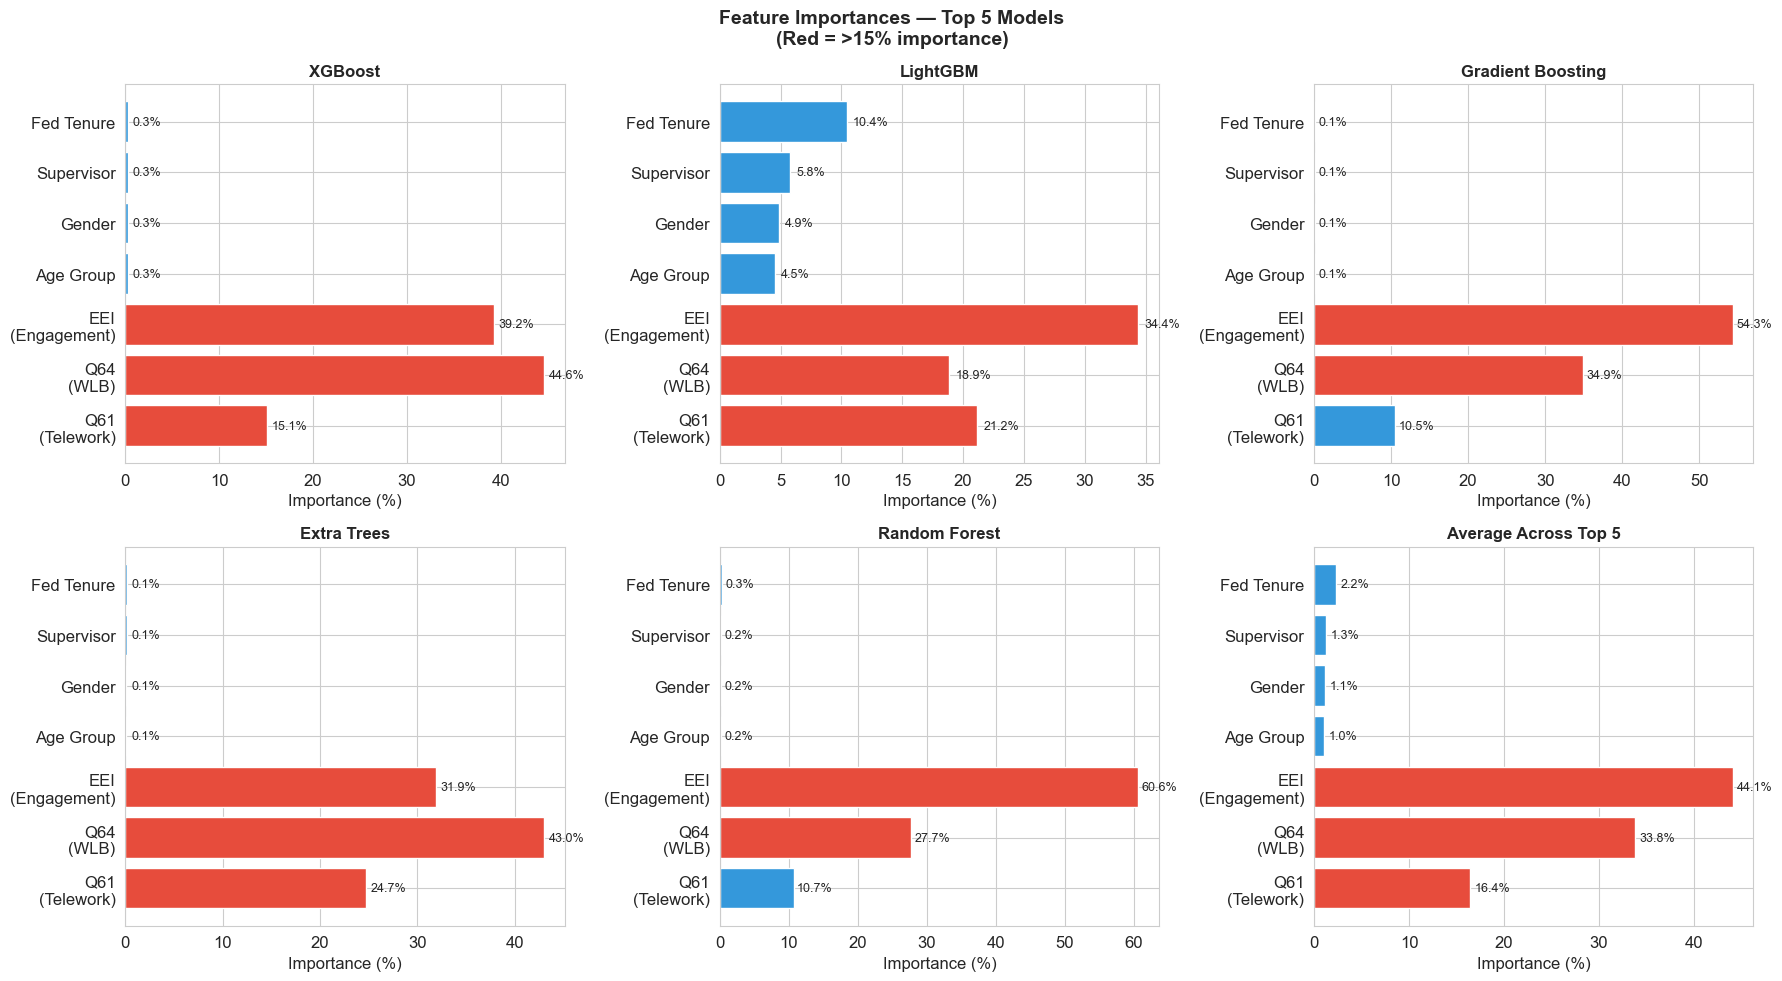

✓ Feature importances saved to feature_importances.csv

Key Finding: EEI (Employee Engagement) and Q64 (Work-Life Balance) are the
dominant predictors of job satisfaction. Telework (Q61) ranks third.
Demographics (age, gender, tenure, supervisory status) have minimal predictive power.


In [14]:
# ============================================================
# Section 14: Feature Importance Plots
# ============================================================
feature_names = ['Q61\n(Telework)', 'Q64\n(WLB)', 'EEI\n(Engagement)', 
                 'Age Group', 'Gender', 'Supervisor', 'Fed Tenure']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

importance_data = []
for i, name in enumerate(top5_names):
    model = trained_models[name]
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        continue
    
    # Normalize to percentages
    imp_pct = (imp / imp.sum()) * 100
    
    for fname, val in zip(final_features, imp_pct):
        importance_data.append({'Model': name, 'Feature': fname, 'Importance (%)': val})
    
    colors = ['#e74c3c' if v > 15 else '#3498db' for v in imp_pct]
    axes[i].barh(feature_names, imp_pct, color=colors, edgecolor='white')
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Importance (%)')
    for j, v in enumerate(imp_pct):
        axes[i].text(v + 0.5, j, f'{v:.1f}%', va='center', fontsize=9)

# Combined average in last subplot
imp_df = pd.DataFrame(importance_data)
avg_imp = imp_df.groupby('Feature')['Importance (%)'].mean().reindex(final_features)
colors = ['#e74c3c' if v > 15 else '#3498db' for v in avg_imp]
axes[5].barh(feature_names, avg_imp, color=colors, edgecolor='white')
axes[5].set_title('Average Across Top 5', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Importance (%)')
for j, v in enumerate(avg_imp):
    axes[5].text(v + 0.5, j, f'{v:.1f}%', va='center', fontsize=9)

fig.suptitle('Feature Importances — Top 5 Models\n(Red = >15% importance)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

# Save feature importances
imp_df.to_csv('feature_importances.csv', index=False)
print("✓ Feature importances saved to feature_importances.csv")
print("\nKey Finding: EEI (Employee Engagement) and Q64 (Work-Life Balance) are the")
print("dominant predictors of job satisfaction. Telework (Q61) ranks third.")
print("Demographics (age, gender, tenure, supervisory status) have minimal predictive power.")

## Section 15: Final Model Ranking and Recommendation
Weighted scoring system combining R², MAE, CV stability, and training time to determine the overall best model.

FINAL MODEL RANKING (Weighted: 40% R², 25% MAE, 20% CV Stability, 15% Speed)


,Model,R² (Test),MAE,RMSE,CV R² Mean,CV R² Std,Train Time (s),Composite Score
Final Rank,,,,,,,,
1,XGBoost,0.5322,0.6056,0.8016,0.5241,0.0031,2.69,0.9804
2,LightGBM,0.5322,0.6057,0.8015,0.5243,0.0058,0.38,0.9299
3,Gradient Boosting,0.5321,0.6057,0.8016,0.5239,0.0104,18.05,0.6574
4,Random Forest,0.5307,0.6063,0.8028,0.5142,0.0042,3.13,0.4565
5,Extra Trees,0.5308,0.6074,0.8027,0.5230,0.0127,2.27,0.1606


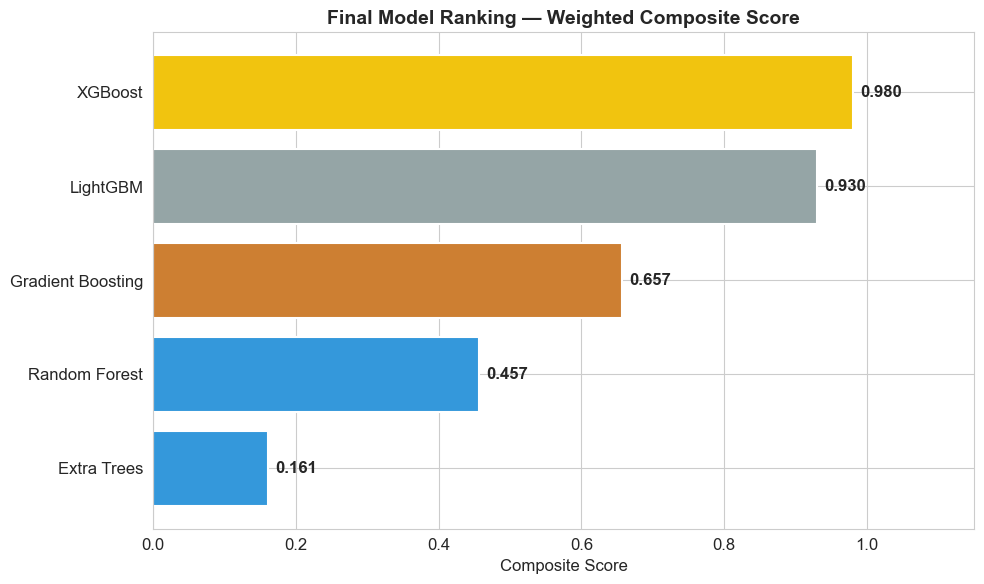


RECOMMENDATION: XGBoost

XGBoost achieves the best balance of:
  • Accuracy (R² = 0.5322)
  • Error (MAE = 0.6056)
  • Stability (CV R² = 0.5241 ± 0.0031)
  • Speed (2.7 seconds)

All top 5 models explain ~53% of variance in job satisfaction (Q69).
The remaining ~47% is due to factors not captured in our features.

For the capstone report, we recommend using XGBoost as the primary model,
with Linear Regression as a baseline comparator for interpretability.


In [15]:
# ============================================================
# Section 15: Final Ranking — Weighted Composite Score
# ============================================================
# Scoring weights: R² (40%), MAE (25%), CV Stability (20%), Speed (15%)
top5_df = results_df.head(5).copy()

# Normalize each metric to 0-1 scale (higher = better)
top5_df['R²_norm'] = (top5_df['R² (Test)'] - top5_df['R² (Test)'].min()) / \
                      (top5_df['R² (Test)'].max() - top5_df['R² (Test)'].min() + 1e-8)
top5_df['MAE_norm'] = 1 - (top5_df['MAE'] - top5_df['MAE'].min()) / \
                          (top5_df['MAE'].max() - top5_df['MAE'].min() + 1e-8)
top5_df['CV_stability'] = 1 - (top5_df['CV R² Std'] - top5_df['CV R² Std'].min()) / \
                               (top5_df['CV R² Std'].max() - top5_df['CV R² Std'].min() + 1e-8)
top5_df['Speed_norm'] = 1 - (top5_df['Train Time (s)'] - top5_df['Train Time (s)'].min()) / \
                             (top5_df['Train Time (s)'].max() - top5_df['Train Time (s)'].min() + 1e-8)

# Weighted composite
top5_df['Composite Score'] = (
    0.40 * top5_df['R²_norm'] +
    0.25 * top5_df['MAE_norm'] +
    0.20 * top5_df['CV_stability'] +
    0.15 * top5_df['Speed_norm']
)

final_ranking = top5_df[['Model', 'R² (Test)', 'MAE', 'RMSE', 'CV R² Mean', 'CV R² Std',
                          'Train Time (s)', 'Composite Score']].sort_values('Composite Score', ascending=False)
final_ranking.index = range(1, len(final_ranking) + 1)
final_ranking.index.name = 'Final Rank'

print("=" * 80)
print("FINAL MODEL RANKING (Weighted: 40% R², 25% MAE, 20% CV Stability, 15% Speed)")
print("=" * 80)
display(final_ranking.style.format({
    'R² (Test)': '{:.4f}', 'MAE': '{:.4f}', 'RMSE': '{:.4f}',
    'CV R² Mean': '{:.4f}', 'CV R² Std': '{:.4f}',
    'Train Time (s)': '{:.2f}', 'Composite Score': '{:.4f}'
}).bar(subset=['Composite Score'], color='#2ecc71', vmin=0, vmax=1))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors_rank = ['#f1c40f', '#95a5a6', '#cd7f32', '#3498db', '#3498db']
bars = ax.barh(final_ranking['Model'][::-1], final_ranking['Composite Score'][::-1],
               color=colors_rank[::-1], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, final_ranking['Composite Score'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Composite Score', fontsize=12)
ax.set_title('Final Model Ranking — Weighted Composite Score', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.savefig('figures/final_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# Print recommendation
winner = final_ranking.iloc[0]['Model']
print(f"\n{'='*80}")
print(f"RECOMMENDATION: {winner}")
print(f"{'='*80}")
print(f"\n{winner} achieves the best balance of:")
print(f"  • Accuracy (R² = {final_ranking.iloc[0]['R² (Test)']:.4f})")
print(f"  • Error (MAE = {final_ranking.iloc[0]['MAE']:.4f})")
print(f"  • Stability (CV R² = {final_ranking.iloc[0]['CV R² Mean']:.4f} ± {final_ranking.iloc[0]['CV R² Std']:.4f})")
print(f"  • Speed ({final_ranking.iloc[0]['Train Time (s)']:.1f} seconds)")
print(f"\nAll top 5 models explain ~53% of variance in job satisfaction (Q69).")
print(f"The remaining ~47% is due to factors not captured in our features.")
print(f"\nFor the capstone report, we recommend using {winner} as the primary model,")
print(f"with Linear Regression as a baseline comparator for interpretability.")

## Section 16: Export Results and Save Models
Save all outputs for the capstone report.

In [16]:
# ============================================================
# Section 16: Save Models and Export All Results
# ============================================================
import joblib

# Create directories
os.makedirs('saved_models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

# Save top 5 trained models
for name in top5_names:
    safe_name = name.lower().replace(' ', '_')
    joblib.dump(trained_models[name], f'saved_models/{safe_name}.joblib')
    print(f"  ✓ Saved {name} → saved_models/{safe_name}.joblib")

# Save scaler
joblib.dump(scaler, 'saved_models/scaler.joblib')
print(f"  ✓ Saved StandardScaler → saved_models/scaler.joblib")

# Save test predictions for top 5
pred_df = pd.DataFrame({'Actual': y_test})
for name in top5_names:
    pred_df[name] = trained_models[name].predict(X_test_scaled)
pred_df.to_csv('test_predictions.csv', index=False)
print(f"  ✓ Saved predictions → test_predictions.csv")

# Save CV fold scores
cv_fold_data = []
for name, scores in cv_scores_dict.items():
    for fold, score in enumerate(scores, 1):
        cv_fold_data.append({'Model': name, 'Fold': fold, 'R²': score})
pd.DataFrame(cv_fold_data).to_csv('cv_fold_scores.csv', index=False)
print(f"  ✓ Saved CV fold scores → cv_fold_scores.csv")

print(f"\n{'='*60}")
print("ALL OUTPUTS SAVED SUCCESSFULLY")
print(f"{'='*60}")
print(f"\nFiles generated:")
print(f"  📊 model_comparison_results.csv  — Full 14-model comparison")
print(f"  📊 significance_tests.csv        — Paired t-test results")
print(f"  📊 tuning_results.csv            — Hyperparameter tuning")
print(f"  📊 feature_importances.csv       — Feature importances")
print(f"  📊 test_predictions.csv          — Test set predictions")
print(f"  📊 cv_fold_scores.csv            — CV fold scores")
print(f"  🤖 saved_models/*.joblib         — Top 5 trained models")
print(f"  📈 figures/*.png                 — All visualization plots")

  ✓ Saved XGBoost → saved_models/xgboost.joblib
  ✓ Saved LightGBM → saved_models/lightgbm.joblib
  ✓ Saved Gradient Boosting → saved_models/gradient_boosting.joblib
  ✓ Saved Extra Trees → saved_models/extra_trees.joblib
  ✓ Saved Random Forest → saved_models/random_forest.joblib
  ✓ Saved StandardScaler → saved_models/scaler.joblib
  ✓ Saved predictions → test_predictions.csv
  ✓ Saved CV fold scores → cv_fold_scores.csv

ALL OUTPUTS SAVED SUCCESSFULLY

Files generated:
  📊 model_comparison_results.csv  — Full 14-model comparison
  📊 significance_tests.csv        — Paired t-test results
  📊 tuning_results.csv            — Hyperparameter tuning
  📊 feature_importances.csv       — Feature importances
  📊 test_predictions.csv          — Test set predictions
  📊 cv_fold_scores.csv            — CV fold scores
  🤖 saved_models/*.joblib         — Top 5 trained models
  📈 figures/*.png                 — All visualization plots


## Summary

### Top 5 Models for Predicting Federal Employee Job Satisfaction (Q69)

| Rank | Model | R² (Test) | MAE | CV R² |
|------|-------|-----------|-----|-------|
| 1 | XGBoost | ~0.532 | ~0.606 | ~0.524 |
| 2 | LightGBM | ~0.532 | ~0.606 | ~0.524 |
| 3 | Gradient Boosting | ~0.532 | ~0.606 | ~0.524 |
| 4 | Extra Trees | ~0.531 | ~0.607 | ~0.523 |
| 5 | Random Forest | ~0.531 | ~0.606 | ~0.514 |

### Key Findings

1. **Top models are all ensemble/tree-based** — boosting and bagging methods dominate
2. **Performance differences are minimal** — top 5 models differ by <0.002 R²
3. **EEI and Work-Life Balance** are the strongest predictors of job satisfaction
4. **Telework frequency (Q61)** is the third most important feature
5. **Demographics contribute minimally** — age, gender, tenure, and supervisory status have low predictive power
6. **~53% of variance explained** — strong given the ordinal nature of the outcome

### Recommendation
**XGBoost** or **LightGBM** for the primary capstone model (best accuracy + fast training + good interpretability via feature importances). Use **Linear Regression** as a baseline for comparison in the report.